# TrAIn.me - Expérience NLP (LSTM)

Ce notebook présente l’utilisation d’un réseau LSTM appliqué au traitement du langage naturel dans le cadre du projet TrAIn.me. 

L’objectif est d’entraîner un modèle séquentiel capable de générer un texte cohérent à partir d’un corpus lié au coaching sportif. 

Les fichiers contenus dans le répertoire `data` sont prétraités, tokenisés et transformés en séquences d’apprentissage adaptées à l’architecture LSTM.


Ce premier POC constitue la baseline du Labo DL-NLP. 

Il permet d’observer le comportement d’un modèle récurrent classique avant d’introduire des variantes (GRU) ou des architectures plus avancées comme les Transformers.

## Concepts clés abordés

- Tokenisation et création de séquences d’apprentissage.
- Représentations vectorielles via les embeddings.
- Capacité de mémoire longue durée propre aux LSTM.
- Génération autoregressive à partir de seeds prédéfinies.


## Imports

In [25]:
# Bibliothèques principales
import re
from pathlib import Path
import random
from pathlib import Path
import json
from datetime import datetime
from IPython.display import clear_output

# Visualisation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Configuration

### Configuration GPU

In [26]:
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

⚠️  Aucun GPU détecté - Utilisation du CPU


### Configuration graphiques

In [27]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Header expérimental

In [28]:
SEED_GLOBAL = 42
SEED_GEN = 123  # pour la génération si tu veux la figer séparément

EPOCHS = 200
BATCH_SIZE = 32
MAX_SEQUENCE_LENGTH = 15  # ou la valeur que tu utilises vraiment
EMBED_DIM = 64
LSTM_UNITS = 128
MODEL_NAME = "lstm_wordlevel_v1"

# CORPUS_LENGTH_PARAM = "_car_180_"
# CORPUS_LENGTH_PARAM = "_car_500_"
# CORPUS_LENGTH_PARAM = "_car_1000_"
# CORPUS_LENGTH_PARAM = "_car_4000_"
# CORPUS_LENGTH_PARAM = "_car_10000_"
# CORPUS_LENGTH_PARAM = "_car_20000_"
CORPUS_LENGTH_PARAM = "_car_FULL_"

# Reproductibilité
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
tf.random.set_seed(SEED_GLOBAL)

### Affichage des versions d'imports

In [29]:
print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")


TensorFlow version: 2.19.1
Keras version: 3.11.2


## Création du corpus des exercices sportifs

Pour cette expérience, nous allons utiliser les fichiers corpus dans "\data\".
C'est un dataset simple mais suffisant pour comprendre les mécanismes des LSTM.

### Concaténation des fichiers .txt

In [30]:
# Chemin du notebook
notebook_dir = Path().resolve()

# Racine du projet = remonter 3 dossiers
project_root = notebook_dir.parent.parent.parent

corpus_dir = project_root / "data"

# Chargement automatique de tous les fichiers .txt dans le dossier data et filtrage dynamique des fichiers .txt contenant le paramètre de longueur
corpus_paths = sorted(
    p for p in corpus_dir.glob("*.txt")
    if CORPUS_LENGTH_PARAM in p.name
)

print("Fichiers détectés :", [p.name for p in corpus_paths])

# Chargement de tous les fichiers texte
corpus_texts = []
for path in corpus_paths:
    with open(path, encoding="utf-8") as f:
        corpus_texts.append(f.read())

# Concaténation POC #1
full_text = "\n".join(text.strip() for text in corpus_texts)

Fichiers détectés : ['corpus_car_FULL_1.txt', 'corpus_car_FULL_2.txt', 'corpus_car_FULL_3.txt']


### Vérifications du corpus

In [31]:
print(f"Corpus créé à partir de {len(corpus_texts)} fichiers texte")

print("\nAperçu du corpus fusionné :")
print(full_text[:500], "...")

Corpus créé à partir de 3 fichiers texte

Aperçu du corpus fusionné :
l'objectif de cette vidéo c'est donc que vous trouviez la meilleure organisation pour vos training et je m'adresse à desgâts naturels en tant que mec naturel et de toute façon il y a que des mecs chargés pour dire oui mais chargé pas chargé c'est pareil pour tout le monde si c'était le cas vous auriez pas besoin de vous charger on va voir dans cette vidéo de la pire façon d'organiser ses entraînements à la meilleure en gros comment diviser vos training pour être le plus efficace possible je vais ...


## Prétraitement du texte

        ◦ POC LSTM word-level (donc POC #1 dans le plan),
        ◦ POC GRU word-level (donc POC #2 dans le plan),
        ◦ et laisser la version word-level pour un autre script plus tard (transformer_train.me.py par exemple).

In [32]:
def clean_text(texte):
    """Nettoie et normalise le texte sans ajouter de tokens inutiles."""
    texte = texte.lower()

    # Supprimer complètement l'apostrophe (sinon elle devient un token)
    texte = texte.replace("'", "")

    # Ajouter des espaces autour de la ponctuation utile
    texte = re.sub(r"([.,!?])", r" \1 ", texte)

    # Supprimer les espaces multiples
    texte = re.sub(r'\s+', ' ', texte)
    return texte.strip()

# Nettoyer le corpus fusionné
full_text_clean = clean_text(full_text)

print("Longueur avant nettoyage :", len(full_text))
print("Longueur après nettoyage :", len(full_text_clean))

print("\nAperçu du texte nettoyé :")
print(full_text_clean[:500], "...")


Longueur avant nettoyage : 51998
Longueur après nettoyage : 51493

Aperçu du texte nettoyé :
lobjectif de cette vidéo cest donc que vous trouviez la meilleure organisation pour vos training et je madresse à desgâts naturels en tant que mec naturel et de toute façon il y a que des mecs chargés pour dire oui mais chargé pas chargé cest pareil pour tout le monde si cétait le cas vous auriez pas besoin de vous charger on va voir dans cette vidéo de la pire façon dorganiser ses entraînements à la meilleure en gros comment diviser vos training pour être le plus efficace possible je vais class ...


## Tokenization

La tokenization convertit le texte en séquences de nombres que le modèle peut comprendre.

In [33]:
# Créer le tokenizer
tokenizer = Tokenizer(filters='', lower=False, oov_token='<UNK>')
tokenizer.fit_on_texts([full_text_clean])

# Statistiques du vocabulaire
vocab_size = len(tokenizer.word_index) + 1  # +1 pour le padding
print(f"Taille du vocabulaire : {vocab_size} mots")
print(f"\nTop 20 mots les plus fréquents :")

# Trier par fréquence
word_freq = sorted(
    tokenizer.word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

for i, (word, freq) in enumerate(word_freq, 1):
    print(f"  {i:2d}. '{word}' : {freq} fois")

Taille du vocabulaire : 1526 mots

Top 20 mots les plus fréquents :
   1. 'vous' : 393 fois
   2. 'de' : 323 fois
   3. 'et' : 220 fois
   4. 'que' : 214 fois
   5. 'le' : 197 fois
   6. 'la' : 195 fois
   7. 'cest' : 179 fois
   8. 'à' : 150 fois
   9. 'pas' : 136 fois
  10. 'en' : 123 fois
  11. 'par' : 122 fois
  12. 'qui' : 113 fois
  13. 'un' : 113 fois
  14. 'les' : 105 fois
  15. 'semaine' : 102 fois
  16. 'ça' : 99 fois
  17. 'fois' : 99 fois
  18. 'une' : 91 fois
  19. 'des' : 90 fois
  20. 'si' : 90 fois


## Préparation des séquences d’entraînement

Pour la génération de texte, nous créons des paires (contexte, mot suivant) :
- Input : "le chat mange"
- Output : "la souris"

In [34]:
SEQ_LEN = MAX_SEQUENCE_LENGTH

def prepare_sequences_from_tokenizer(text: str, tokenizer, seq_len: int):
    tokens = tokenizer.texts_to_sequences([text])[0]

    sequences = []
    for i in range(seq_len, len(tokens)):
        seq = tokens[i-seq_len:i+1]  # contexte + mot cible
        sequences.append(seq)

    return sequences, tokens

sequences, all_tokens = prepare_sequences_from_tokenizer(
    text=full_text_clean,
    tokenizer=tokenizer,
    seq_len=SEQ_LEN
)

print(f"\nNombre total de séquences : {len(sequences)}")

# Conversion en tableau numpy
sequences_array = np.array(sequences)

# X = les seq_len premiers tokens, y = le token cible (dernier)
X = sequences_array[:, :-1]
y_indices = sequences_array[:, -1]

# One-hot sur la cible
y = to_categorical(y_indices, num_classes=vocab_size)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)



Nombre total de séquences : 9364
Forme de X : (9364, 15)
Forme de y : (9364, 1526)


## Pourquoi choisir SEQ_LEN = 15 (ou 20, ou 30) ?

Parce que le LSTM est performant sur :

- des dépendances courtes (5 à 20 mots),
- parfois moyennes (30 à 50 mots),
- mais jamais longues (100+ mots).

Un LSTM :
- garde des états internes (mémoire courte, mémoire longue),
- mais sa capacité de mémoire diminue exponentiellement avec la longueur de la séquence,
- donc plus la séquence est longue → plus le signal se dilue → plus le modèle oublie ce qui s’est passé en début de phrase.

On appelle ça le :

➡ vanishing gradient (le gradient s’évanouit)

## Pourquoi ne pas mettre SEQ_LEN = 200 alors ?

Deux raisons :

1 — Explosion de la RAM & temps d'entraînement

Plus tu augmentes SEQ_LEN, plus :
- X est immense
- y est coûteux
- le nombre de séquences chute
- l’entraînement devient instable
- la mémoire GPU sature

Un LSTM séquentiel ne peut pas gérer de très longues séquences.

2 — Bruit inutile

Au-delà de 20-30 tokens, le LSTM “oublie” ce qu’il voit.

Ajouter du bruit n’aide pas, au contraire.


Dimensions des données :
  X (input)  : (9364, 15) - (nombre_sequences, longueur_sequence-1)
  y (output) : (9364, 1526) - (nombre_sequences, vocab_size)

  Longueur maximale de séquence : [16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 1

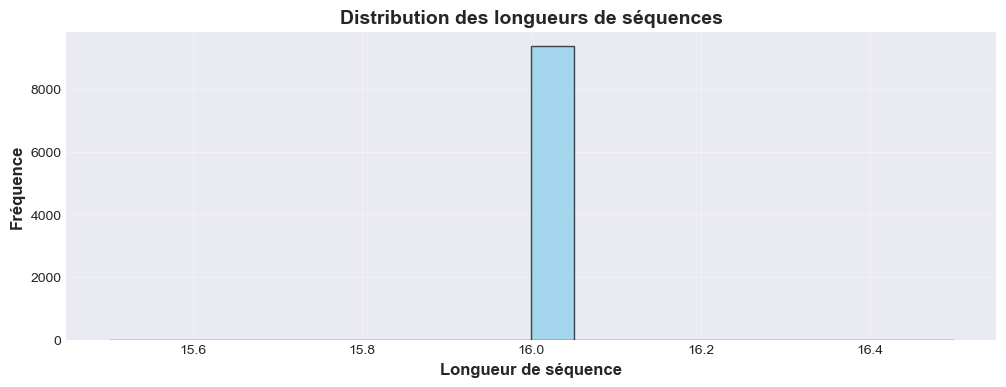

In [35]:
sequence_lengths = [len(seq) for seq in sequences]

print(f"\nDimensions des données :")
print(f"  X (input)  : {X.shape} - (nombre_sequences, longueur_sequence-1)")
print(f"  y (output) : {y.shape} - (nombre_sequences, vocab_size)")
print(f"\n  Longueur maximale de séquence : {sequence_lengths}")

# Visualisation de la distribution des longueurs
sequence_lengths = [len([x for x in seq if x != 0]) for seq in sequences]
plt.figure(figsize=(12, 4))
plt.hist(sequence_lengths, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Longueur de séquence', fontsize=12, fontweight='bold')
plt.ylabel('Fréquence', fontsize=12, fontweight='bold')
plt.title('Distribution des longueurs de séquences', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

## Construction du dataset séquentiel

Ajouter un split train/val juste après la création des séquences

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=SEED_GLOBAL,
    shuffle=True
)

## Modèle Baseline : LSTM (Approche Traditionnelle)

Avant de plonger dans les Transformers, créons un modèle LSTM comme référence.

### Architecture LSTM

Les LSTM (Long Short-Term Memory) sont des RNN améliorés qui :
- Traitent les séquences de manière **séquentielle** (un mot après l'autre)
- Maintiennent une **mémoire** des informations passées
- Peuvent capturer des **dépendances à long terme**

**Limitations** :
- Traitement séquentiel (pas de parallélisation)
- Difficulté avec les très longues séquences
- Gradient vanishing/exploding

### Fonction de création du modèle

In [37]:
def create_lstm_model(
    vocab_size,
    max_length,
    embedding_dim=100,
    lstm_units=128,
    name="lstm_model"
):
    """Crée un modèle LSTM pour la génération de texte."""

    model = models.Sequential(name=name)

    # Couche d'embedding : convertit les tokens en vecteurs denses
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        name='embedding'
    ))
    
    # Couches LSTM
    model.add(layers.LSTM(lstm_units, return_sequences=True, name='lstm_1'))
    model.add(layers.Dropout(0.2, name='dropout_1'))
    
    model.add(layers.LSTM(lstm_units, name='lstm_2'))
    model.add(layers.Dropout(0.2, name='dropout_2'))
    
    # Couche dense finale
    model.add(layers.Dense(vocab_size, activation='softmax', name='output'))

    return model

In [38]:
create_lstm_model

<function __main__.create_lstm_model(vocab_size, max_length, embedding_dim=100, lstm_units=128, name='lstm_model')>

### Création du modèle

In [39]:
# Créer le modèle LSTM
lstm_model = create_lstm_model(
    vocab_size=vocab_size,
    max_length=MAX_SEQUENCE_LENGTH,
    embedding_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    name=MODEL_NAME
)

# Compiler
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modèle LSTM créé !\n")
print(lstm_model)
print(lstm_model.layers)

# Forcer la construction du modèle
lstm_model.build(input_shape=(None, MAX_SEQUENCE_LENGTH - 1))

print("\nAprès build explicite :")
lstm_model.summary()
print("Count params:", lstm_model.count_params())
print("Trainable vars:", len(lstm_model.trainable_variables))
print("Non-trainable vars:", len(lstm_model.non_trainable_variables))

Modèle LSTM créé !

<Sequential name=lstm_wordlevel_v1, built=False>
[<Embedding name=embedding, built=False>, <LSTM name=lstm_1, built=False>, <Dropout name=dropout_1, built=True>, <LSTM name=lstm_2, built=False>, <Dropout name=dropout_2, built=True>, <Dense name=output, built=False>]

Après build explicite :


Model: "lstm_wordlevel_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 64)         │        97,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1526)           │       196,854 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,918 (2.00 MB)

 Trainable params: 524,918 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

Count params: 524918
Trainable vars: 9
Non-trainable vars: 4


## Callbacks

### Callbacks Early stopping pour éviter l'overfitting

In [40]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,             # 5 epochs sans amélioration → stop
    restore_best_weights=True
)

### Checkpoint pour sauvegarder le meilleur modèle

In [41]:
checkpoint_path = project_root / "models" / f"{MODEL_NAME}.keras"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_loss',
    save_best_only=True,
    verbose=1  # ⬅ plus de logs "Epoch X: ..."
)

print(f"Checkpoint path : {checkpoint_path}")

Checkpoint path : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\lstm_wordlevel_v1.keras


### Callback pour visualiser la progression

In [42]:
class TrainingProgressCallback(Callback):
    def __init__(self):
        super().__init__()
        self.losses = []
        self.accuracies = []
        
    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs['loss'])
        self.accuracies.append(logs['accuracy'])
        
        if (epoch + 1) % 1 == 0:
            clear_output(wait=True)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
            
            # Loss
            ax1.plot(self.losses, color='red', linewidth=2, marker='o', markersize=4)
            ax1.set_title('Loss (LSTM)', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Epoch', fontsize=12)
            ax1.set_ylabel('Loss', fontsize=12)
            ax1.grid(alpha=0.3)
            
            # Accuracy
            ax2.plot(self.accuracies, color='green', linewidth=2, marker='o', markersize=4)
            ax2.set_title('Accuracy (LSTM)', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Epoch', fontsize=12)
            ax2.set_ylabel('Accuracy', fontsize=12)
            ax2.grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"Epoch {epoch + 1}/{self.params['epochs']} - "
                  f"Loss: {logs['loss']:.4f} - Accuracy: {logs['accuracy']:.4f}")

# Callback
progress_callback_lstm = TrainingProgressCallback()

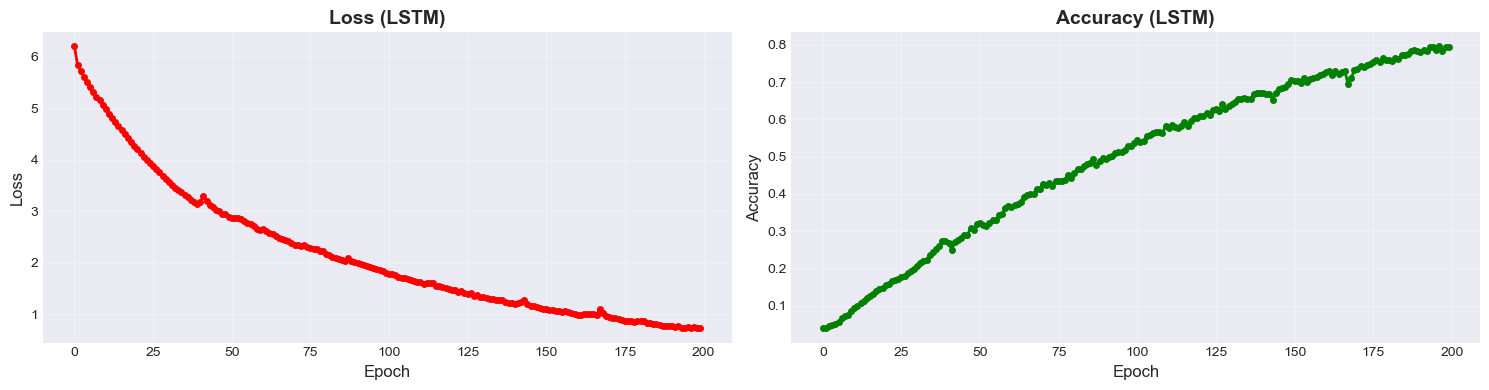

Epoch 200/200 - Loss: 0.7185 - Accuracy: 0.7957

Epoch 200: val_loss did not improve from 5.95114

Entraînement LSTM terminé !


In [43]:
# Entraînement du modèle LSTM
print("Début de l'entraînement du modèle LSTM...\n")

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=0,
    # callbacks=[progress_callback_lstm, early_stopping, checkpoint]
    callbacks=[progress_callback_lstm, checkpoint]
    # callbacks=[progress_callback_lstm]
)


print("\nEntraînement LSTM terminé !")

### Perplexité

In [44]:
final_loss = history_lstm.history["val_loss"][-1]
perplexity = np.exp(final_loss)
print(f"Perplexité approx: {perplexity:.2f}")

Perplexité approx: 103222.83


## Test de génération de texte avec LSTM

In [45]:
def generate_text(model, tokenizer, seed_text, num_words=10, temperature=1.0, seed=None):
    """
    Génère du texte à partir d'un texte de départ.
    
    Parameters:
    - temperature: Contrôle la créativité (0.5=conservateur, 1.0=équilibré, 2.0=créatif)
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random

    generated_text = seed_text
    
    for _ in range(num_words):
        # Tokenize le texte actuel
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = pad_sequences([token_list], maxlen=MAX_SEQUENCE_LENGTH-1, padding='pre')
        
        # Prédiction
        predictions = model.predict(token_list, verbose=0)[0]
        
        # Appliquer la température
        predictions = np.log(predictions + 1e-7) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))
        
        # Choisir le prochain mot
        predicted_id = rng.choice(len(predictions), p=predictions)
        
        # Convertir l'ID en mot
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                predicted_word = word
                break
        
        if predicted_word:
            generated_text += " " + predicted_word
    
    return generated_text

# Tests de génération avec différents seeds
print("Génération de texte avec LSTM\n")
print("=" * 80)

seeds = [
    "perdre du gras et prendre du muscle",
    "3 séances de sport par semaine",
    "Je me suis fait une entorse à la cheville droite",
    "passif de Judoka et tennis",
    " reprendre le sport au sein d’une salle de sport"
]

for i, seed in enumerate(seeds):
    generated = generate_text(
        lstm_model, tokenizer,
        seed_text=seed,
        num_words=8,
        temperature=0.8,
        seed=SEED_GEN + i  # pour rester reproductible mais varier un peu
    )
    print(f"\nSeed: '{seed}'")
    print(f"> Généré: {generated}")
    print("-" * 80)

Génération de texte avec LSTM


Seed: 'perdre du gras et prendre du muscle'
> Généré: perdre du gras et prendre du muscle une fois par semaine cest la moitié une
--------------------------------------------------------------------------------

Seed: '3 séances de sport par semaine'
> Généré: 3 séances de sport par semaine sauf une stimuler un exercices stimuler une fois
--------------------------------------------------------------------------------

Seed: 'Je me suis fait une entorse à la cheville droite'
> Généré: Je me suis fait une entorse à la cheville droite une séance parce que vous allez avoir un
--------------------------------------------------------------------------------

Seed: 'passif de Judoka et tennis'
> Généré: passif de Judoka et tennis le dirty body cest-à-dire les séances mais moi
--------------------------------------------------------------------------------

Seed: ' reprendre le sport au sein d’une salle de sport'
> Généré:  reprendre le sport au sein d’une sall

## Génération de texte : tests qualitatifs

In [46]:
# Comparaison de génération de texte
print("\n" + "=" * 90)
print(" " * 20 + "COMPARAISON DE GÉNÉRATION DE TEXTE")
print("=" * 90)

test_seeds = [
    "perdre du gras et prendre du muscle",
    "3 séances de sport par semaine",
    "Je me suis fait une entorse à la cheville droite",
    "passif de Judoka et tennis",
    " reprendre le sport au sein d’une salle de sport"
]

for seed in test_seeds:
    print(f"\nSeed: '{seed}'")
    print("-" * 90)
    
    # LSTM
    lstm_gen = generate_text(lstm_model, tokenizer, seed, num_words=10, temperature=0.7)
    print(f"> LSTM       : {lstm_gen}")
    print()


                    COMPARAISON DE GÉNÉRATION DE TEXTE

Seed: 'perdre du gras et prendre du muscle'
------------------------------------------------------------------------------------------
> LSTM       : perdre du gras et prendre du muscle une fois par semaine cest le ppl il faut dabord


Seed: '3 séances de sport par semaine'
------------------------------------------------------------------------------------------
> LSTM       : 3 séances de sport par semaine vous restez comme vous allez vous entraîner quand vous avez


Seed: 'Je me suis fait une entorse à la cheville droite'
------------------------------------------------------------------------------------------
> LSTM       : Je me suis fait une entorse à la cheville droite un plus temps en fait cas que vous y pas


Seed: 'passif de Judoka et tennis'
------------------------------------------------------------------------------------------
> LSTM       : passif de Judoka et tennis sûr ça vous app quand vous allez faire chaque 

## Test avec différentes températures

La température contrôle la créativité :
- **Basse (0.5)** : Conservateur, prévisible
- **Moyenne (1.0)** : Équilibré
- **Haute (2.0)** : Créatif, surprenant

In [47]:
# Test avec différentes températures
print("\n" + "=" * 90)
print(" " * 25 + "EFFET DE LA TEMPÉRATURE")
print("=" * 90)

seed_test = "perdre du gras et prendre du muscle"
temperatures = [0.5, 1.0, 1.5, 2.0]

print(f"\nSeed: '{seed_test}'\n")

for temp in temperatures:
    print(f"\nTempérature: {temp}")
    print("-" * 90)
    
    # Générer plusieurs fois pour montrer la variabilité
    for i in range(3):
        gen_text = generate_text(lstm_model, tokenizer, seed_test, num_words=8, temperature=temp)
        print(f"  {i+1}. {gen_text}")


                         EFFET DE LA TEMPÉRATURE

Seed: 'perdre du gras et prendre du muscle'


Température: 0.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle au moins possible daccord si vous en half
  2. perdre du gras et prendre du muscle une fois par semaine cest le half body
  3. perdre du gras et prendre du muscle une fois par semaine cest le même muscle

Température: 1.0
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle au moins beaucoup de la fois il faut
  2. perdre du gras et prendre du muscle une fois par semaine cest le mettre est
  3. perdre du gras et prendre du muscle une fois par semaine cest le half body

Température: 1.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle le salle cest une fois stimuler ok donc
  2. perdre 

## Carnet d’expériences

In [48]:
logs_dir = project_root / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

experiment_filename = logs_dir / f"experiment_{MODEL_NAME}.json"

timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
experiment_filename = logs_dir / f"experiment_{MODEL_NAME}_{timestamp}.json"

experiment_log = {
    "model_name": MODEL_NAME,
    "vocab_size": vocab_size,
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "final_train_loss": float(history_lstm.history["loss"][-1]),
    "final_val_loss": float(history_lstm.history.get("val_loss", [np.nan])[-1]),
    "perplexity": float(perplexity),
    "seeds": seeds,
}

print("\n===== RÉSUMÉ EXPÉRIMENTAL =====")
for k, v in experiment_log.items():
    print(f"- {k}: {v}")

with open(experiment_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\nLog expérimental sauvegardé : {experiment_filename}")



===== RÉSUMÉ EXPÉRIMENTAL =====
- model_name: lstm_wordlevel_v1
- vocab_size: 1526
- max_sequence_length: 15
- epochs: 200
- batch_size: 32
- final_train_loss: 0.7185013294219971
- final_val_loss: 11.544645309448242
- perplexity: 103222.8280340337
- seeds: ['perdre du gras et prendre du muscle', '3 séances de sport par semaine', 'Je me suis fait une entorse à la cheville droite', 'passif de Judoka et tennis', ' reprendre le sport au sein d’une salle de sport']

Log expérimental sauvegardé : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\logs\experiment_lstm_wordlevel_v1_20251119-192537.json
